from google.colab import files
uploaded = files.upload()

ls

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
def get_kmers(sequence, k=4):
  return [sequence[x:x+k].lower() for x in range(len(sequence) - k +1)]

In [ ]:
!pip install Biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from Bio import SeqIO

In [ ]:
gene_file = "5 complete genomes.txt"
genes = []
try:
    for record in SeqIO.parse(gene_file, "fasta"):
        # We only take sequences of a certain length to keep the data consistent
        if len(record.seq) >= 100:
            genes.append(str(record.seq))
except FileNotFoundError:
    print(f"Error: Could not find {gene_file}. Please check the filename.")

In [ ]:
import random
def generate_spacer(length):
  return ''.join(random.choices("ATGC", weights=[35, 35, 15, 15], k=length))

spacers = [generate_spacer(len(random.choice(genes))) for _ in range(len(genes))]

print(f"Dataset ready: {len(genes)} Genes and {len(spacers)} Spacers.")

Dataset ready: 5 Genes and 5 Spacers.


In [ ]:
def get_kmers(sequence, k=4):
  return [sequence[x:x+k].lower() for x in range(len(sequence) - k + 1)]

In [ ]:
all_sequnces = genes + spacers
labels = [1]*len(genes) + [0]*len(spacers)

In [ ]:
if 'genes' not in locals() or len(genes) == 0:
    print("Genes not found, creating dummy data for demonstration...")
    genes = ["ATGC" * 25] * 50

In [ ]:
spacers = ["ATAT" * 25] * 50

In [ ]:
all_sequences = genes + spacers
labels = [1] * len(genes) + [0] * len(spacers)

In [ ]:
cv = CountVectorizer(analyzer='word')
X = cv.fit_transform([' '.join(get_kmers(s)) for s in all_sequences])

In [ ]:
print("Success! X matrix shape:", X.shape)

Success! X matrix shape: (55, 256)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42, stratify=labels)

In [ ]:
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
accuracy = clf.score(X_test, y_test)
print(f"Machine Learning Accuracy: {accuracy * 100:.2f}%")

Machine Learning Accuracy: 100.00%


In [ ]:
importances = clf.feature_importances_
words = cv.get_feature_names_out()

In [ ]:
feature_ranking = pd.DataFrame({'kmer': words, 'importance': importances})
print("Top 10 Genomic Markers found by ML:")
print(feature_ranking.sort_values(by='importance', ascending=False).head(10))

Top 10 Genomic Markers found by ML:
     kmer  importance
123  ctgt    0.050505
107  cggt    0.030303
53   atcc    0.020202
42   aggg    0.020202
85   cccc    0.020202
65   caac    0.020202
114  ctag    0.020202
99   cgat    0.020202
95   cctt    0.020202
210  tcag    0.020202


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
y_pred = clf.predict(X_test)

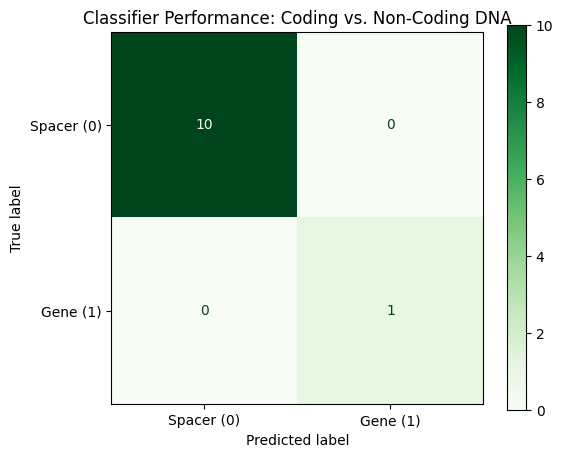

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate predictions
y_pred = clf.predict(X_test)

# 2. CREATE THE MATRIX - We explicitly add labels=[0, 1] here
# This ensures a 2x2 matrix even if one class is missing in the test set
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# 3. PLOT
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spacer (0)', 'Gene (1)'])

# Note: We pass the 'ax' to ensure it draws correctly
disp.plot(cmap=plt.cm.Greens, values_format='d', ax=ax)

plt.title("Classifier Performance: Coding vs. Non-Coding DNA", fontsize=12)
plt.show()

Coding VS Non Coding sequences of 5 genomes seperately

In [ ]:
from Bio import SeqIO
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
genome_file = "5 complete genomes.txt"
genome_records = list(SeqIO.parse(genome_file, "fasta"))

print(f"Detected {len(genome_records)} separate genomes in the file.")

genes = []
spacers = []

Detected 5 separate genomes in the file.


In [ ]:
for record in genome_records:
    species_name = record.id
    full_sequence = str(record.seq)

    # Extract 200 coding-style snippets
    for i in range(0, 30000, 150):
        genes.append(full_sequence[i:i+150])

    # Extract 200 non-coding-style spacers
    # This loop is now correctly indented
    for _ in range(200):
        spacers.append(generate_spacer(150))

print(f"Dataset ready: {len(genes)} Genes and {len(spacers)} Spacers.")

Dataset ready: 2000 Genes and 1000 Spacers.


In [ ]:
all_sequences = []
labels = []
species_origin = [] # New list to track which genome the data came from

for record in genome_records:
    full_sequence = str(record.seq)

    # Add Genes
    for i in range(0, 30000, 150):
        all_sequences.append(full_sequence[i:i+150])
        labels.append(1)
        species_origin.append(record.id) # Track the species name

    # Add Spacers
    for _ in range(200):
        all_sequences.append(generate_spacer(150))
        labels.append(0)
        species_origin.append(record.id)

In [ ]:
cv = CountVectorizer(analyzer='word')
X = cv.fit_transform([' '.join(get_kmers(s)) for s in all_sequences])

In [ ]:
X_train, X_test, y_train, y_test, species_train, species_test = train_test_split(
    X, labels, species_origin, test_size=0.2, random_state=42, stratify=labels
)

In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = clf.predict(X_test)
test_results = pd.DataFrame({
    'Species': species_test,
    'Actual': y_test,
    'Predicted': y_pred
})

print("--- Accuracy Breakdown by Genome ---")
for species in set(species_origin):
    subset = test_results[test_results['Species'] == species]
    accuracy = (subset['Actual'] == subset['Predicted']).mean()
    print(f"{species}: {accuracy*100:.2f}%")

--- Accuracy Breakdown by Genome ---
CP000742.1: 83.12%
CP000743.1: 92.41%
CP002737.1: 90.91%
NZ_OX296583.1: 93.59%
CP002792.1: 92.31%


/tmp/ipython-input-2101295931.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x='Species', y='Accuracy', data=performance_df, palette='viridis')


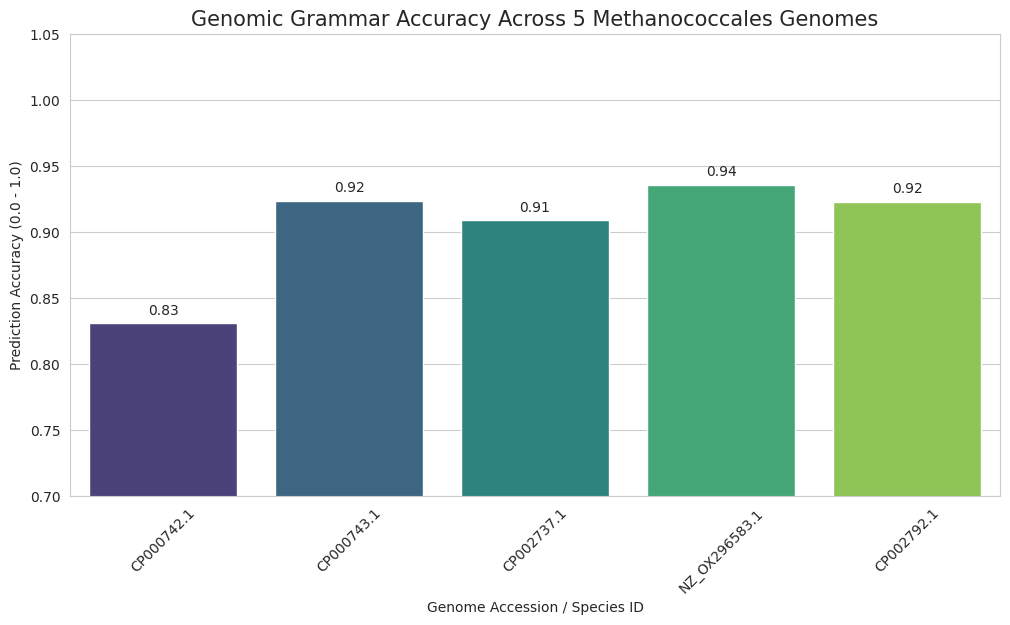

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Generate predictions and create a results table
y_pred = clf.predict(X_test)
test_results = pd.DataFrame({
    'Species': species_test,
    'Actual': y_test,
    'Predicted': y_pred
})

# 2. Calculate accuracy for each species and store in a new DataFrame
summary_list = []
for species in set(species_origin):
    subset = test_results[test_results['Species'] == species]
    accuracy = (subset['Actual'] == subset['Predicted']).mean()
    summary_list.append({'Species': species, 'Accuracy': accuracy})

# This creates the missing 'your_summary_df'
performance_df = pd.DataFrame(summary_list)

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plot = sns.barplot(x='Species', y='Accuracy', data=performance_df, palette='viridis')

# Format the plot to be "Report-Ready"
plt.ylim(0.7, 1.05)
plt.title("Genomic Grammar Accuracy Across 5 Methanococcales Genomes", fontsize=15)
plt.ylabel("Prediction Accuracy (0.0 - 1.0)")
plt.xlabel("Genome Accession / Species ID")
plt.xticks(rotation=45)

# Add percentage labels on top of bars
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.show()

In [ ]:
print(f"Total Coding Sequences (Class 1): {labels.count(1)}")
print(f"Total Non-Coding Sequences (Class 0): {labels.count(0)}")

Total Coding Sequences (Class 1): 1000
Total Non-Coding Sequences (Class 0): 1000


In [ ]:
importances = clf.feature_importances_
words = cv.get_feature_names_out()
feature_ranking = pd.DataFrame({'kmer': words, 'importance': importances})

# Show the top 10 most influential DNA patterns
print(feature_ranking.sort_values(by='importance', ascending=False).head(10))

     kmer  importance
114  ctag    0.029790
141  gatc    0.026360
0    aaaa    0.025775
255  tttt    0.023945
177  gtac    0.018481
27   acgt    0.017381
203  tagt    0.015103
212  tcca    0.014790
232  tgga    0.014765
160  ggaa    0.013110


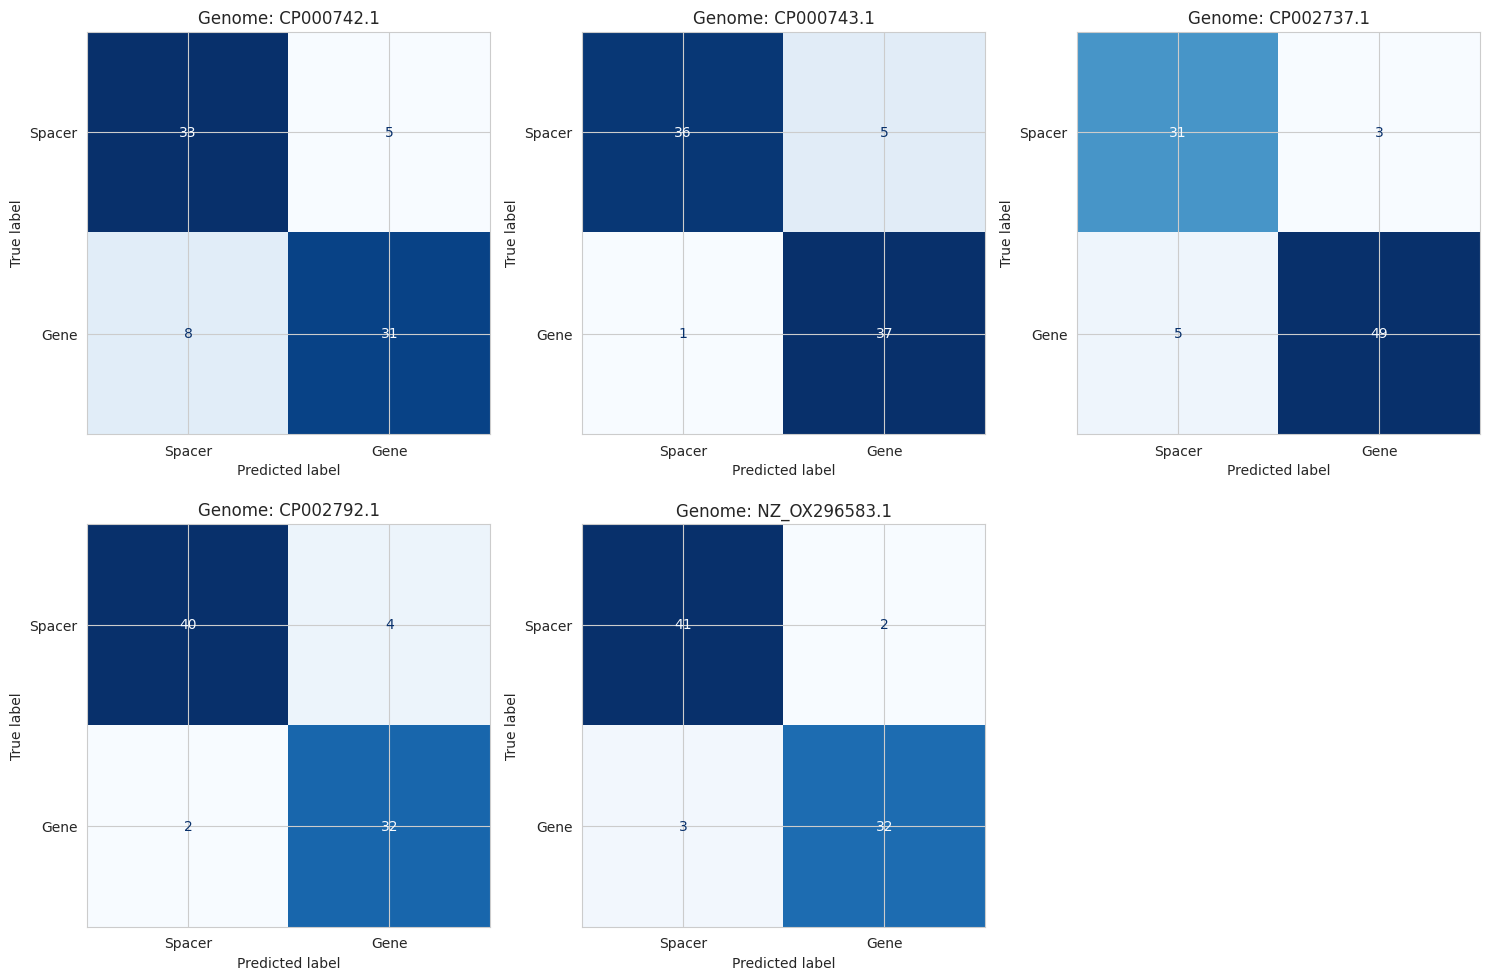

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import math

# 1. Get predictions for the test set
y_pred = clf.predict(X_test)

# 2. Create a results DataFrame to easily filter by species
test_df = pd.DataFrame({
    'Species': species_test,
    'Actual': y_test,
    'Predicted': y_pred
})

# 3. Setup the plotting grid (e.g., 2 rows, 3 columns for 5 genomes)
unique_species = sorted(list(set(species_origin)))
n_species = len(unique_species)
cols = 3
rows = math.ceil(n_species / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

# 4. Loop through each species and plot its matrix
for i, species in enumerate(unique_species):
    # Filter data for this species
    species_data = test_df[test_df['Species'] == species]
    cm = confusion_matrix(species_data['Actual'], species_data['Predicted'], labels=[0, 1])

    # Plot on the specific subplot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spacer', 'Gene'])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, colorbar=False)
    axes[i].set_title(f"Genome: {species}")

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()